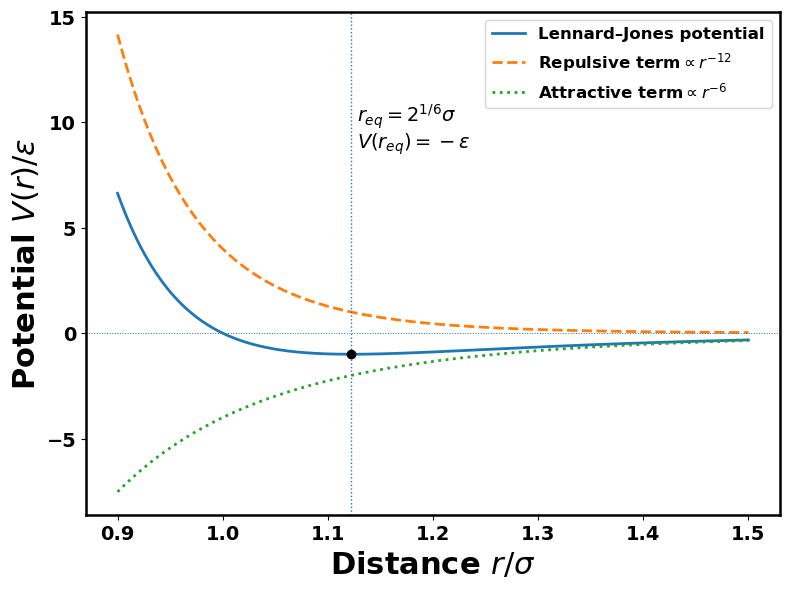

In [1]:
import numpy as np
import matplotlib.pyplot as plt

r = np.linspace(0.9, 1.5, 500)
epsilon, sigma = 1, 1

V = 4*epsilon*((sigma/r)**12 - (sigma/r)**6)
V_rep = 4*epsilon*(sigma/r)**12
V_att = -4*epsilon*(sigma/r)**6

rmin = 2**(1/6)
Vmin = -epsilon

fig, ax = plt.subplots(figsize=(8, 6))
for spine in ax.spines.values():
    spine.set_linewidth(1.8)
    
plt.plot(r, V, lw=2, label="Lennard–Jones potential")
plt.plot(r, V_rep, "--", lw=2, label=r"Repulsive term$\propto r^{-12}$")
plt.plot(r, V_att, ":", lw=2, label=r"Attractive term$\propto r^{-6}$")
plt.scatter(rmin, Vmin, color="black", zorder=5)
plt.axvline(rmin, linestyle=":", linewidth=1)

plt.axhline(0, linewidth=0.7,linestyle=":")
plt.text(rmin+0.005, 10, r"$r_{eq} = 2^{1/6}\sigma$", fontsize=14)
plt.text(rmin+0.005, 8.8, r"$V(r_{eq})=-\varepsilon$", fontsize=14)

plt.xlabel(r"Distance $r/\sigma$", fontsize=22, fontweight="bold")
plt.ylabel(r"Potential $V(r)/\varepsilon$", fontsize=22, fontweight="bold")
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.legend(loc="upper right", prop={"size": 12, "weight": "bold"})
plt.tight_layout()
plt.savefig("lj_potential.pdf")
plt.show()

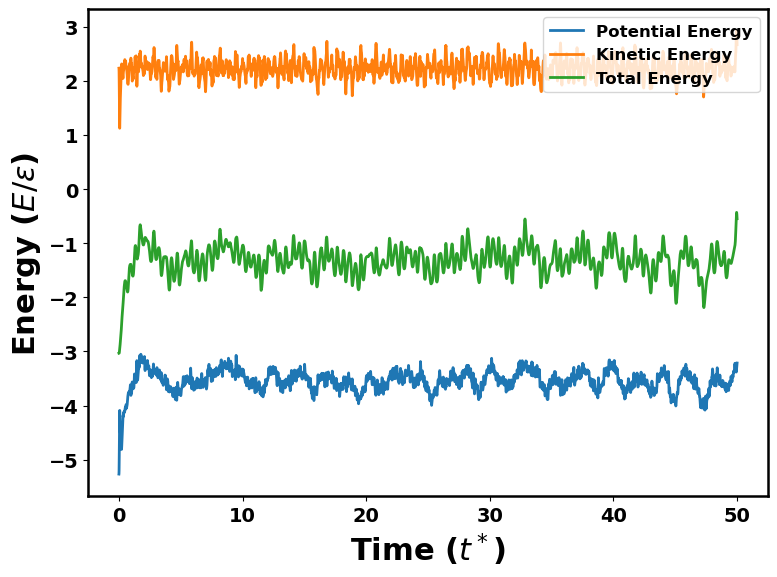

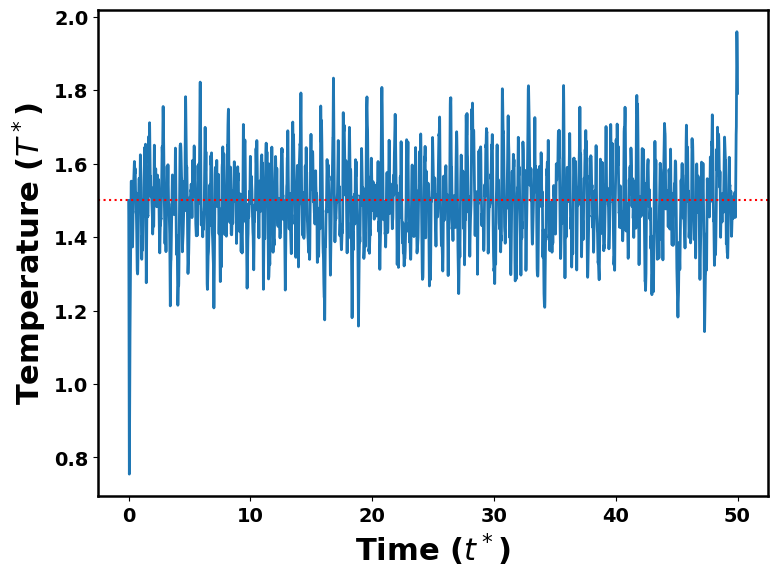

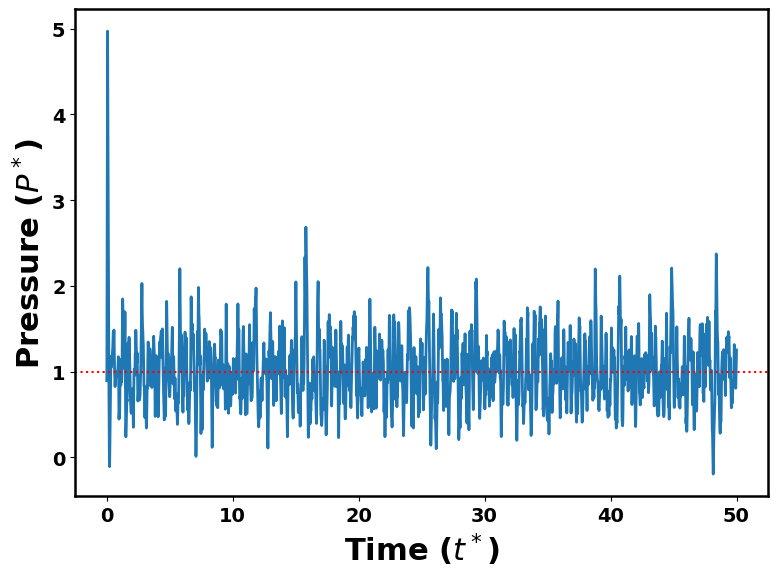

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# User settings
# =========================
file_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/equilibration data/npt_ts0.001.csv"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# Set the number of atoms in your simulation
N_atoms = 125   # <-- change this to your actual number of atoms

# If you want to remove 3 translational degrees of freedom, set this to True
remove_com_motion = False

# =========================
# Read CSV
# =========================
df = pd.read_csv(file_path)

# Extract columns 0-5: Time, PotEng, KinEng, TotEng, Temp, Press
data = df.iloc[:, 0:6].copy()
data.columns = ["Time", "PotEng", "KinEng", "TotEng", "Temp", "Press"]

# Convert to numeric in case there are stray strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Drop rows with missing values
data = data.dropna()

# =========================
# Global plotting style
# =========================
plt.rcParams.update({
    "font.size": 14
})

# ============================================================
# ENERGY FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8,6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["Time"], data["PotEng"], lw=2, label="Potential Energy")
ax.plot(data["Time"], data["KinEng"], lw=2, label="Kinetic Energy")
ax.plot(data["Time"], data["TotEng"], lw=2, label="Total Energy")

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Energy ($E/\varepsilon$)", fontsize=22, fontweight="bold")

#ax.set_title("Energy vs Time (NPT, timestep=0.001)", fontsize=20, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper right", prop={"size":12, "weight":"bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "energy_vs_time_ts0.001.pdf"))
plt.show()


# ============================================================
# TEMPERATURE FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8,6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["Time"], data["Temp"], lw=2)
ax.axhline(1.5, linestyle=":", lw=1.5, color="red")

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Temperature ($T^*$)", fontsize=22, fontweight="bold")

#ax.set_title("Temperature vs Time (NPT, timestep=0.001)", fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "temperature_vs_time_ts0.001.pdf"))
plt.show()


# ============================================================
# PRESSURE FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8,6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["Time"], data["Press"], lw=2)
ax.axhline(1, linestyle=":", lw=1.5, color="red")

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Pressure ($P^*$)", fontsize=22, fontweight="bold")

#ax.set_title("Pressure vs Time (NPT, timestep=0.001)", fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "pressure_vs_time_ts0.001.pdf"))
plt.show()

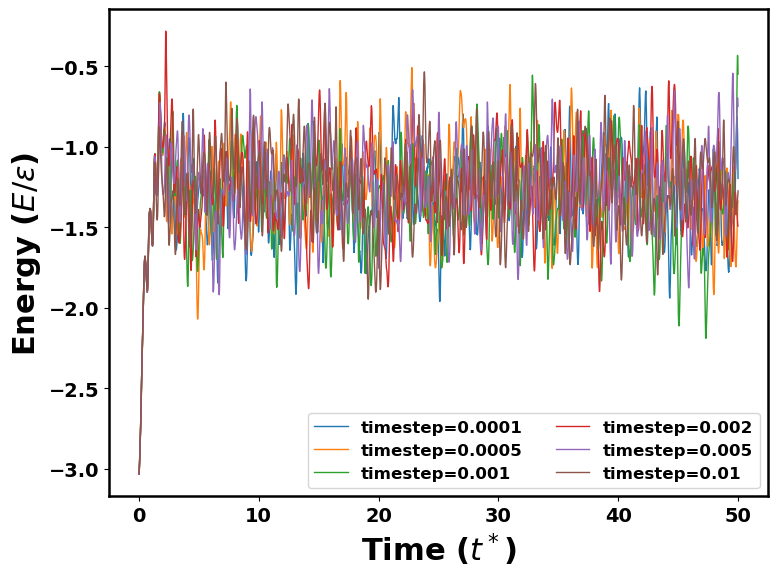

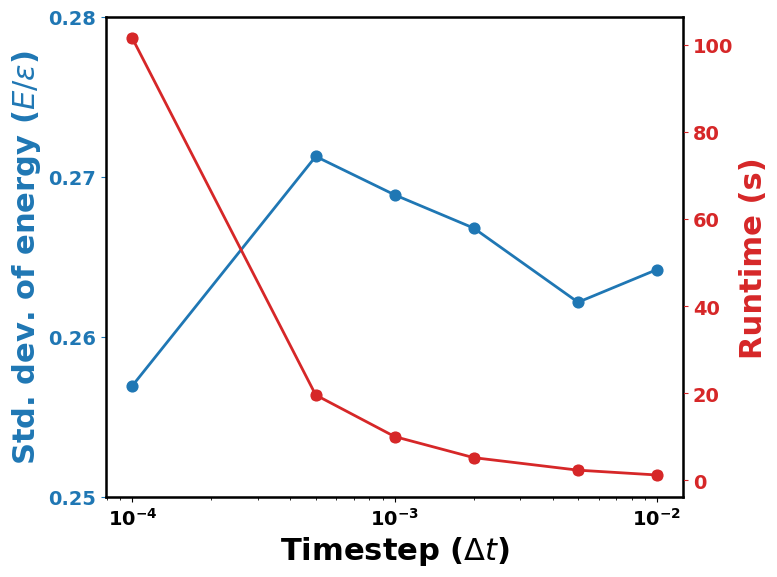

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# =========================
# User settings
# =========================
file_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/equilibration data/npt_energy_time_different_ts.csv"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# =========================
# Read CSV
# =========================
df = pd.read_csv(file_path, skiprows=1)

data = df.iloc[:, 0:12].copy()
data.columns = [
    "Time_0.0001", "TotEng_0.0001",
    "Time_0.0005", "TotEng_0.0005",
    "Time_0.001",  "TotEng_0.001",
    "Time_0.002",  "TotEng_0.002",
    "Time_0.005",  "TotEng_0.005",
    "Time_0.01",   "TotEng_0.01"
]

# Convert to numeric in case there are stray strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# =========================
# Global plotting style
# =========================
plt.rcParams.update({
    "font.size": 14
})

timesteps = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]

# ============================================================
# ENERGY FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

for ts in timesteps:
    ax.plot(
        data[f"Time_{ts}"],
        data[f"TotEng_{ts}"],
        lw=1,
        label=f"timestep={ts}"
    )

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Energy ($E/\varepsilon$)", fontsize=22, fontweight="bold")
#ax.set_title("Energy vs Time (NPT) with different timestep", fontsize=20, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="lower right", prop={"size": 12, "weight": "bold"}, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "energy_vs_time_different_ts.pdf"))
plt.show()

# ============================================================
# STD + RUNTIME VS TIMESTEP (DUAL AXIS FIGURE)
# ============================================================

timesteps = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]
loop_time = [101.453, 19.5833, 10.0399, 5.21044, 2.33439, 1.22569]

# ---- compute std ----
std_values = []
for ts in timesteps:
    series = data[f"TotEng_{ts}"].dropna()
    std_values.append(series.std())

fig, ax1 = plt.subplots(figsize=(8,6))

# axis spine style
for spine in ax1.spines.values():
    spine.set_linewidth(1.8)

# ============================================================
# LEFT AXIS (Energy fluctuation)
# ============================================================

ax1.plot(timesteps, std_values, marker="o", lw=2, color="tab:blue")
ax1.scatter(timesteps, std_values, s=60, zorder=3, color="tab:blue")

ax1.set_xlabel(r"Timestep ($\Delta t$)", fontsize=22, fontweight="bold")
ax1.set_ylabel(r"Std. dev. of energy ($E/\varepsilon$)", fontsize=22, fontweight="bold", color="tab:blue")

ax1.set_ylim(0.25, 0.28)

ax1.set_xscale("log")

ax1.tick_params(axis='both', labelsize=14)

# ============================================================
# RIGHT AXIS (Runtime)
# ============================================================

ax2 = ax1.twinx()

ax2.plot(timesteps, loop_time, marker="s", lw=2, color="tab:red")
ax2.scatter(timesteps, loop_time, s=60, zorder=3, color="tab:red")

ax2.set_ylabel("Runtime (s)", fontsize=22, fontweight="bold", color="tab:red")

# ============================================================
# Ticks + layout
# ============================================================

ax1.tick_params(axis='y', colors="tab:blue")
ax1.set_yticks([0.25, 0.26, 0.27, 0.28])
ax2.tick_params(axis='y', colors="tab:red")

for label in ax1.get_xticklabels():
    label.set_fontweight("bold")

for label in ax1.get_yticklabels():
    label.set_fontweight("bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "timestep_stability_runtime.pdf"))
plt.show()